# Module 2.6 — Lid-Driven Cavity Flow

**The "Hello World" of incompressible CFD.**
Every new N-S solver is validated against this case. The geometry is trivially simple — a unit square — yet the physics is rich enough to test pressure-velocity coupling, boundary conditions, and convergence at any Reynolds number.

**Why this case matters:**
Ghia, Ghia & Shin (1982) published reference solutions at Re = 100, 400, 1000, 3200, 5000 that are still used today. If your solver does not match these numbers, it is wrong — regardless of whether it converges. Beautiful streamline plots with wrong velocity profiles are still wrong.

**Roadmap:**
1. Problem setup — geometry, BCs, expected physics
2. Flow structure as a function of Re
3. The complete solver — explicit time-stepping toward steady state
4. Validation against Ghia et al. (1982) benchmark data
5. Convergence study — confirming mesh independence
6. Common failure modes and how to diagnose them

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Problem Setup

### Geometry and boundary conditions

```
     u = 1, v = 0   ← moving lid (top wall)
    ─────────────────────────────────────
    │                                   │
u=0 │                                   │ u=0
v=0 │    Fluid (Re = UL/ν, U=1, L=1)    │ v=0
    │                                   │
    ─────────────────────────────────────
         u = 0, v = 0  ← fixed bottom wall
```

Domain: $[0,1] \times [0,1]$
- **Top wall** ($y=1$): $u = 1$, $v = 0$ — the lid that drives the flow
- **Bottom, left, right walls**: $u = v = 0$ — no-slip
- **Pressure**: Neumann ($\partial p/\partial n = 0$) on all walls, mean removed to fix the additive constant

The Reynolds number: $Re = UL/\nu$ with $U=1$, $L=1$, so $\nu = 1/Re$.

### What physics to expect

At low Re: the lid drags the fluid in a single large recirculating vortex. The vortex centre sits near the geometric centre, slightly off-axis because viscosity is asymmetric.

As Re increases, the primary vortex strengthens and its centre moves toward the geometric centre. Secondary vortices appear in the bottom corners — the primary vortex drives a recirculation there. At Re > 7500, the flow becomes time-periodic (unsteady).

### The validation target — Ghia et al. (1982)

Ghia, Ghia & Shin solved this problem on a $129 \times 129$ grid using a multigrid vorticity-streamfunction formulation. Their table of $u$ velocity along the vertical centreline ($x=0.5$) is the standard reference:

| $y$ | $u$ at $x=0.5$ (Re=100) |
|-----|---------------------------|
| 1.0000 | 1.0000 |
| 0.9766 | 0.8486 |
| 0.9688 | 0.8300 |
| 0.9609 | 0.8102 |
| 0.9531 | 0.7902 |
| ... | ... |
| 0.0000 | 0.0000 |

Your solver passes the test if the $u$ profile at $x=0.5$ matches these values.

Running lid-driven cavity at Re=100 ...
Done.


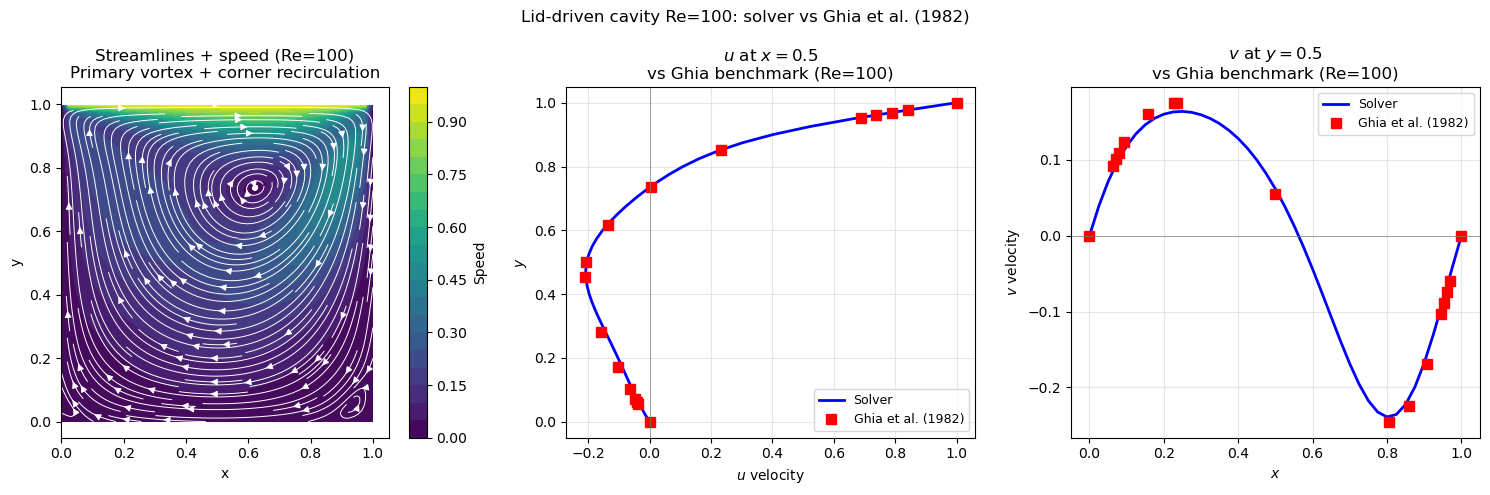

Max error vs Ghia u-profile: 0.0133
  < 0.02: excellent   < 0.05: good   > 0.1: suspect your solver


In [2]:
# ── Lid-driven cavity solver ─────────────────────────────────────────────────
# Explicit time-stepping toward steady state.
# Fractional-step method: advance momentum, then correct with Poisson.

def lid_driven_cavity(Re, N, n_steps, dt):
    """
    Re:      Reynolds number (= 1/nu for U=L=1)
    N:       grid points per side
    n_steps: number of time steps
    dt:      time step size
    Returns: u, v, p field arrays
    """
    nu  = 1.0 / Re
    rho = 1.0
    dx = dy = 1.0 / (N-1)

    # ── Initialise ────────────────────────────────────────────────────────────
    u = np.zeros((N, N))
    v = np.zeros((N, N))
    p = np.zeros((N, N))
    u[-1, :] = 1.0   # lid moves at u=1

    def poisson_step(p, b, nit=50):
        """Jacobi Poisson solver, fixed iterations."""
        for _ in range(nit):
            p[1:-1,1:-1] = (
                (p[1:-1,2:]+p[1:-1,:-2])/dx**2 +
                (p[2:,1:-1]+p[:-2,1:-1])/dy**2 - b[1:-1,1:-1]
            ) / (2/dx**2 + 2/dy**2)
            p[0,:]=p[1,:]; p[-1,:]=p[-2,:]
            p[:,0]=p[:,1]; p[:,-1]=p[:,-2]
        return p

    # ── Time loop ─────────────────────────────────────────────────────────────
    for _ in range(n_steps):
        un, vn = u.copy(), v.copy()

        # ── PPE RHS (from velocity divergence) ───────────────────────────────
        b = np.zeros_like(p)
        b[1:-1,1:-1] = (rho/dt * (
            (un[1:-1,2:]-un[1:-1,:-2])/(2*dx) +
            (vn[2:,1:-1]-vn[:-2,1:-1])/(2*dy))
            - ((un[1:-1,2:]-un[1:-1,:-2])/(2*dx))**2
            - 2*((un[2:,1:-1]-un[:-2,1:-1])/(2*dy))*((vn[1:-1,2:]-vn[1:-1,:-2])/(2*dx))
            - ((vn[2:,1:-1]-vn[:-2,1:-1])/(2*dy))**2)

        p = poisson_step(p, b)

        # ── Momentum update (explicit Euler) ─────────────────────────────────
        u[1:-1,1:-1] = (
            un[1:-1,1:-1]
            - un[1:-1,1:-1]*dt/dx*(un[1:-1,1:-1]-un[1:-1,:-2])
            - vn[1:-1,1:-1]*dt/dy*(un[1:-1,1:-1]-un[:-2,1:-1])
            - dt/(2*rho*dx)*(p[1:-1,2:]-p[1:-1,:-2])
            + nu*dt/dx**2*(un[1:-1,2:]-2*un[1:-1,1:-1]+un[1:-1,:-2])
            + nu*dt/dy**2*(un[2:,1:-1]-2*un[1:-1,1:-1]+un[:-2,1:-1]))

        v[1:-1,1:-1] = (
            vn[1:-1,1:-1]
            - un[1:-1,1:-1]*dt/dx*(vn[1:-1,1:-1]-vn[1:-1,:-2])
            - vn[1:-1,1:-1]*dt/dy*(vn[1:-1,1:-1]-vn[:-2,1:-1])
            - dt/(2*rho*dy)*(p[2:,1:-1]-p[:-2,1:-1])
            + nu*dt/dx**2*(vn[1:-1,2:]-2*vn[1:-1,1:-1]+vn[1:-1,:-2])
            + nu*dt/dy**2*(vn[2:,1:-1]-2*vn[1:-1,1:-1]+vn[:-2,1:-1]))

        # ── BCs ───────────────────────────────────────────────────────────────
        u[0,:]=0; u[-1,:]=1.0; u[:,0]=0; u[:,-1]=0
        v[0,:]=0; v[-1,:]=0;   v[:,0]=0; v[:,-1]=0

    return u, v, p

# ── Run solver ────────────────────────────────────────────────────────────────
print('Running lid-driven cavity at Re=100 ...')
N  = 41
dt = 0.001
u, v, p = lid_driven_cavity(Re=100, N=N, n_steps=5000, dt=dt)
print('Done.')

# ── Ghia et al. (1982) benchmark data for Re=100 ──────────────────────────────
# u-velocity along vertical centreline x=0.5
ghia_y = [0.0000, 0.0547, 0.0625, 0.0703, 0.1016, 0.1719, 0.2813,
          0.4531, 0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609,
          0.9688, 0.9766, 1.0000]
ghia_u = [0.0000,-0.0372,-0.0419,-0.0477,-0.0643,-0.1015,-0.1566,
         -0.2109,-0.2058,-0.1364, 0.0033, 0.2315, 0.6872, 0.7372,
          0.7887, 0.8412, 1.0000]

# v-velocity along horizontal centreline y=0.5
ghia_x_v = [0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266,
             0.2344, 0.5000, 0.8047, 0.8594, 0.9063, 0.9453, 0.9531,
             0.9609, 0.9688, 1.0000]
ghia_v =  [0.0000, 0.0923, 0.1009, 0.1089, 0.1232, 0.1608, 0.1751,
           0.1753, 0.0545,-0.2453,-0.2245,-0.1691,-0.1031,-0.0886,
          -0.0739,-0.0601, 0.0000]

# ── Extract centre-line profiles from solver ─────────────────────────────────
x_arr = np.linspace(0, 1, N)
y_arr = np.linspace(0, 1, N)
j_mid = N // 2   # j index nearest y=0.5
i_mid = N // 2   # i index nearest x=0.5

Xg, Yg = np.meshgrid(x_arr, y_arr)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Streamlines ───────────────────────────────────────────────────────────────
speed = np.sqrt(u**2 + v**2)
cf = axes[0].contourf(Xg, Yg, speed, levels=20, cmap='viridis')
plt.colorbar(cf, ax=axes[0], label='Speed')
axes[0].streamplot(Xg, Yg, u, v, color='white', density=1.8, linewidth=0.7)
axes[0].set_title('Streamlines + speed (Re=100)\nPrimary vortex + corner recirculation')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# ── u-velocity profile at x=0.5 ───────────────────────────────────────────────
axes[1].plot(u[:, i_mid], y_arr, 'b-', lw=2, label='Solver')
axes[1].plot(ghia_u, ghia_y, 'rs', markersize=7, label='Ghia et al. (1982)')
axes[1].axvline(0, color='gray', lw=0.5)
axes[1].set_xlabel('$u$ velocity'); axes[1].set_ylabel('$y$')
axes[1].set_title('$u$ at $x=0.5$\nvs Ghia benchmark (Re=100)')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# ── v-velocity profile at y=0.5 ───────────────────────────────────────────────
axes[2].plot(x_arr, v[j_mid, :], 'b-', lw=2, label='Solver')
axes[2].plot(ghia_x_v, ghia_v, 'rs', markersize=7, label='Ghia et al. (1982)')
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].set_xlabel('$x$'); axes[2].set_ylabel('$v$ velocity')
axes[2].set_title('$v$ at $y=0.5$\nvs Ghia benchmark (Re=100)')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.suptitle('Lid-driven cavity Re=100: solver vs Ghia et al. (1982)', fontsize=12)
plt.tight_layout()
plt.show()

# ── Quantitative match check ──────────────────────────────────────────────────
# Interpolate solver u-profile to Ghia y-locations
u_solver_at_ghia = np.interp(ghia_y, y_arr, u[:, i_mid])
max_err = np.max(np.abs(u_solver_at_ghia - ghia_u))
print(f'Max error vs Ghia u-profile: {max_err:.4f}')
print(f'  < 0.02: excellent   < 0.05: good   > 0.1: suspect your solver')

## 2. Common Failure Modes — How to Diagnose Them

| Symptom | Most likely cause | Diagnosis |
|---------|------------------|----------|
| Solution blows up immediately | CFL violated | Reduce dt, check $\nu\cdot dt/dx^2 < 0.5$ |
| Converges but wrong profile | Wrong pressure BC | Check $dp/dn=0$ on all walls; check pressure mean removed |
| Symmetric flow (should have slight asymmetry) | Wrong lid BC | Check u[-1,:]=1 not u[:,0]=1 |
| Large divergence that doesn't decrease | Too few Poisson iterations | Increase `nit` in Poisson solver to 100+ |
| Profile matches Ghia at Re=100 but fails at Re=1000 | Grid too coarse | Double the grid resolution |
| Slow convergence to steady state | Time stepping too aggressive | Use smaller dt or increase Poisson iterations |

### The Ghia check is mandatory

Before claiming your solver works:
1. Run Re = 100, N = 41
2. Extract $u$ at $x = 0.5$
3. Compare to Ghia et al. — max error should be $< 0.02$
4. Run Re = 400, N = 65
5. Repeat

If you skip this step and move to more complex flows, you will waste time debugging problems that were present in your base solver.

## Summary

| Aspect | Key point |
|--------|-----------|
| Geometry | Unit square, lid moves at $u=1$, all other walls no-slip |
| Physics | Primary vortex + bottom corner vortices; structure changes with Re |
| Validation | Must match Ghia et al. (1982) centreline profiles |
| Typical Re range | 100–3200 (laminar, steady) |
| First check | $u$ at $x=0.5$ within 2% of Ghia; zero divergence to machine precision |

---
**Next:** Module 2.7 — Flow Over a Cylinder: external flow, Kármán vortex shedding, lift and drag.

## Exercise

**Predict first, then verify.**

1. Run the solver at Re=400. Predict: does the primary vortex centre move toward or away from the geometric centre compared to Re=100? Compare your result to Ghia et al. Re=400 data.

2. **Mesh convergence study:** Run on N=21, N=41, N=81. Plot the max error in the $u$ centreline profile against $\Delta x$. What order of convergence do you observe? Is it consistent with the scheme order?

3. The bottom-left corner vortex at Re=100 is very weak. Find its approximate centre coordinates $(x,y)$ by looking for where the streamfunction has a local extremum. Does it match the Ghia result?